In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
## load the dataset

DATA_PATH = "Fraud.csv"
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
df.head()
print("dataset loaded successfully!")


dataset loaded successfully!


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
#EDA
print("Dataset shape:", df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df["isFraud"].value_counts())
print("Fraud ratio:", df["isFraud"].mean())


Dataset shape: (6362620, 11)
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud ratio: 0.001290820448180152


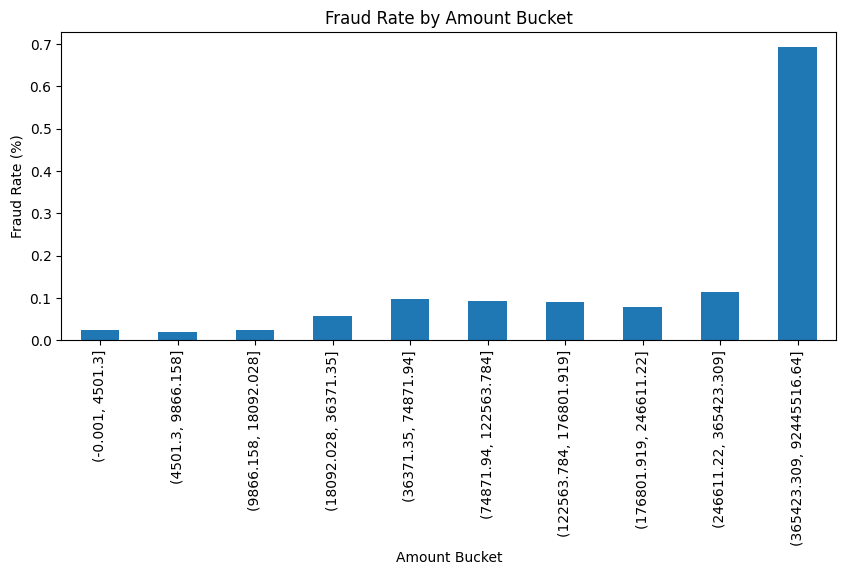

In [11]:
## Fraud rate by amount bucket
df["amount_bin"] = pd.qcut(df["amount"], q=10, duplicates="drop")

fraud_rate = df.groupby("amount_bin")["isFraud"].mean()
fraud_rate = fraud_rate * 100  # convert to percentage

plt.figure(figsize=(10, 4))
fraud_rate.plot(kind="bar")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Amount Bucket")
plt.title("Fraud Rate by Amount Bucket")
plt.show()




In [12]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
amount_bin        0
dtype: int64

In [16]:
#check merchant transaction counts
merchant_txns = df[df["nameDest"].str.startswith('M')]
merchant_txnas = merchant_txns[['oldbalanceDest','newbalanceDest']].describe()

In [17]:
merchant_txnas

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [18]:
# no true missing values

Text(0.5, 1.0, 'Distribution of Transaction Amount')

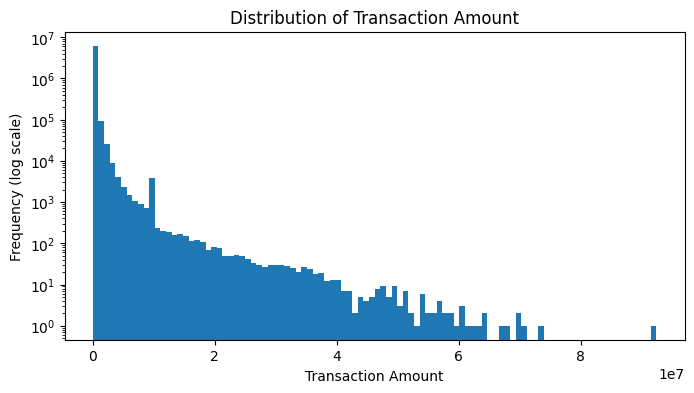

In [19]:
#Outliners Handling

df['amount'].describe()

#Visualize skewness
plt.figure(figsize=(8, 4))
plt.hist(df["amount"],bins = 100)
plt.yscale("log")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Transaction Amount")

In [20]:
#log transformation to reduce skewness
df['log_amount'] = np.log1p(df['amount'])

#flag transactions above 99th percentile
p99 = df['amount'].quantile(0.99)
df['is_high_amount'] = (df['amount'] > p99).astype(int)

df['is_high_amount'].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

In [21]:
#overview
total_txns = len(df)
fraud_txns = df['isFraud'].sum()

fraud_rate = fraud_txns / total_txns 
fraud_pct = (df['isFlaggedFraud'].sum() / total_txns) * 100

print(f"Total transactions: {total_txns}")
print(f"Fraudulent transactions: {fraud_txns} ({fraud_rate:.4%})")
print(f"Flagged fraudulent transactions: {df['isFlaggedFraud'].sum()} ({fraud_pct:.4f}%)")

Total transactions: 6362620
Fraudulent transactions: 8213 (0.1291%)
Flagged fraudulent transactions: 16 (0.0003%)


<Axes: xlabel='type'>

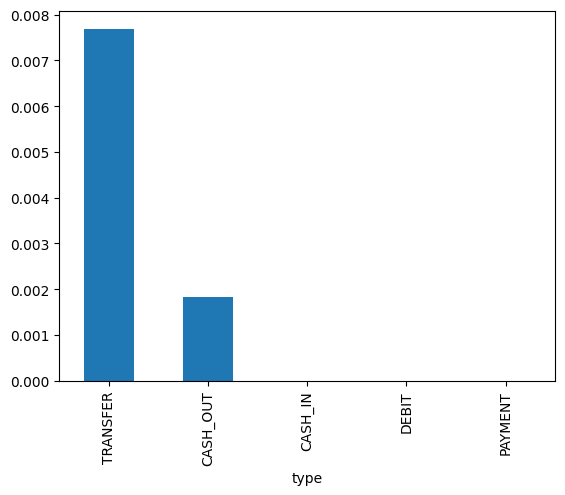

In [23]:
df.groupby("type")["isFraud"].mean().sort_values(ascending=False).plot(kind="bar")

In [24]:
#time based fraud analysis 

df['hour'] = df['step'] % 24

hourly_stats = (
    df.groupby("hour").agg(
        total_transactions=("isFraud", "count"),
        fraud_transactions=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean")
    ).reset_index()
)

display(hourly_stats)


,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790
5,5,1641,366,0.223035
6,6,3420,358,0.104678
7,7,8988,328,0.036493
8,8,26915,368,0.013673
9,9,283518,341,0.001203


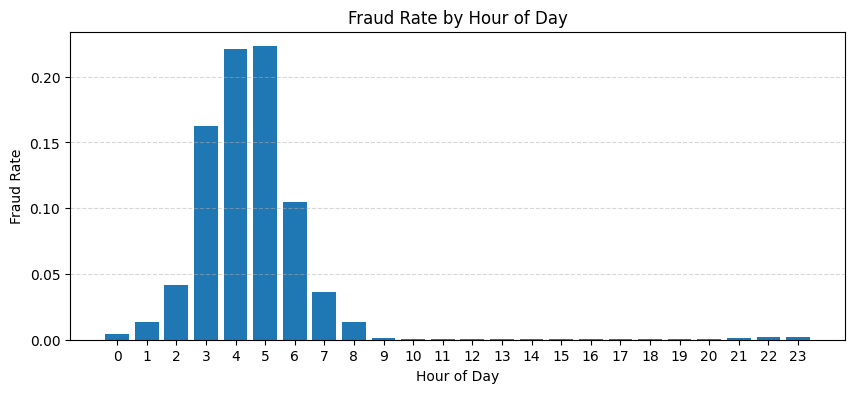

In [25]:
plt.figure(figsize=(10, 4))
plt.bar(hourly_stats['hour'], hourly_stats['fraud_rate'])
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour of Day")
plt.xticks(range(0, 24))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

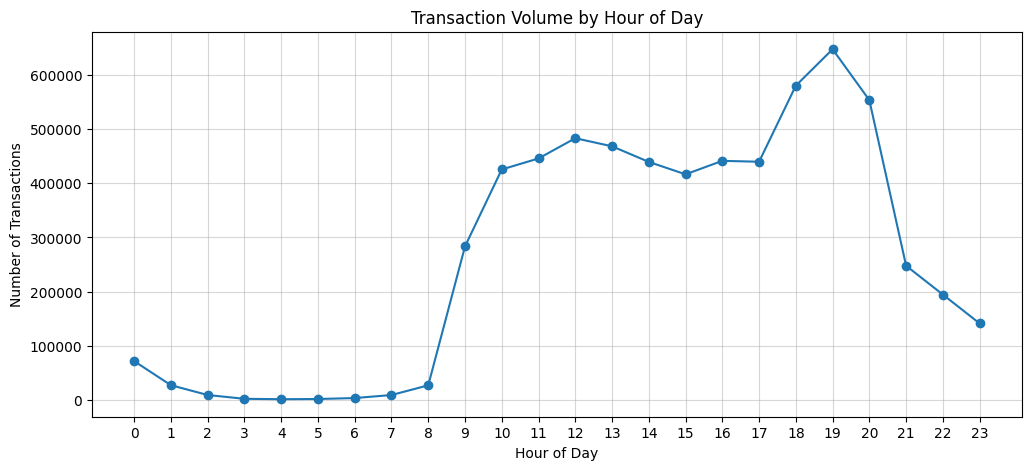

In [26]:
plt.figure(figsize=(12,5))
plt.plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Volume by Hour of Day')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
plt.show()

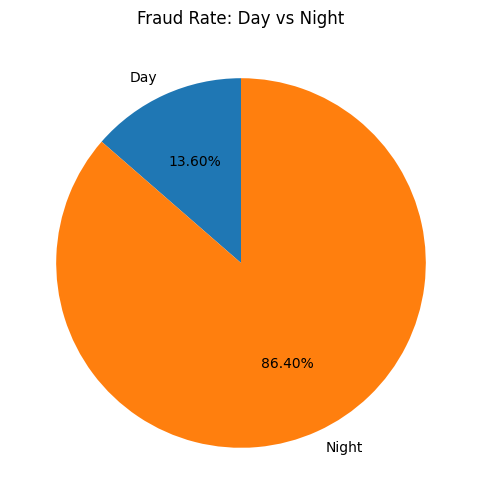

In [27]:
plt.figure(figsize=(6,6))

df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

day_night_fraud = (
    df.groupby('is_night')['isFraud']
      .mean()  # average fraud rate
      .rename({0: 'Day', 1: 'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',      
    startangle=90,
    legend=False
)

plt.ylabel('') 
plt.title('Fraud Rate: Day vs Night')
plt.show()

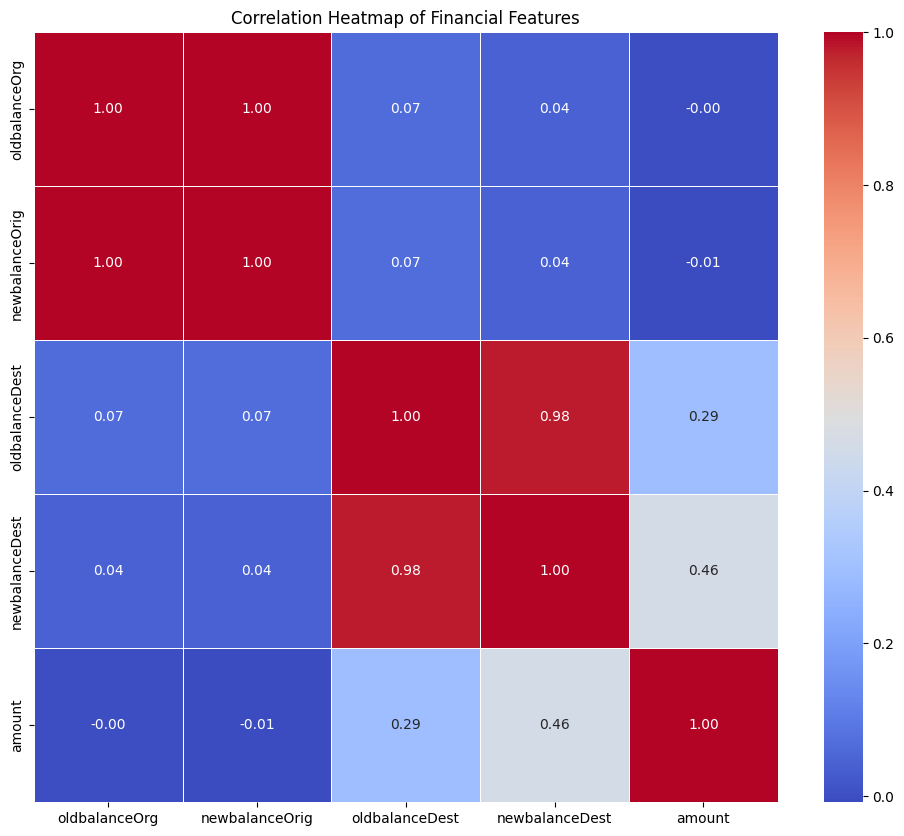

In [28]:
#Correlation heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
corr = df[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Financial Features")
plt.show()

In [29]:
#feature engg and cleaning 
df["balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balance_diff_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]


# Feature Reduction
df = df.drop(columns=['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'])

In [30]:
df.drop(columns = ['amount_bin'], inplace=True)

df.fillna(0, inplace=True)

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

df.drop(columns=['type', 'nameOrig', 'nameDest'],axis = 1, inplace=True)

In [31]:
## Train test split

x = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

scaler = RobustScaler()
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [33]:
models = []

models = {}

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=300, solver = 'lbfgs',class_weight='balanced',n_jobs=-1)
lr.fit(X_train, y_train)
models['Logistic Regression'] = lr
print("Logistic Regression trained successfully!")

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=12, min_samples_leaf=100, class_weight='balanced', n_jobs=-1,random_state=42)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("Random Forest trained successfully!")

print("Training XGBoost...")
scale_pos = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb = XGBClassifier(n_estimators=50, max_depth=6, scale_pos_weight=scale_pos,learning_rate=0.1,subsample = 0.8,colsample_bytree = 0.8, eval_metric='logloss', tree_method='hist', n_jobs = -1)
xgb.fit(X_train, y_train)
models['XGBoost'] = xgb
print("XGBoost trained successfully!")


Training Logistic Regression...
Logistic Regression trained successfully!
Training Random Forest...
Random Forest trained successfully!
Training XGBoost...
XGBoost trained successfully!


In [35]:

from sklearn.metrics import average_precision_score
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    print('\n',name)
    print(classification_report(y_test, y_pred))
    
    results.append({
        'Model': name,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'avprc' : average_precision_score(y_test, y_proba)})
    


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524


 Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.05      0.93      0.10      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.95      0.54   1272524
weighted avg       1.00      0.98      0.99   1272524


 XGBoost
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.03      0.96      0.07      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.96      0.52   1272524
weighted avg       1.00   

In [37]:
results

[{'Model': 'Logistic Regression',
  'roc_auc': 0.9776370011936115,
  'avprc': 0.5504503407504904},
 {'Model': 'Random Forest',
  'roc_auc': 0.9925536891936226,
  'avprc': 0.7508953993653811},
 {'Model': 'XGBoost',
  'roc_auc': 0.9938873636842305,
  'avprc': 0.7040900882892587}]

In [38]:
## while all models achieve hight ROC-AUC, the average precision score (AP) is more informative for imbalanced datasets. The AP scores indicate that while the models can rank transactions well (high ROC-AUC), their ability to identify true positives among the predicted positives is limited (lower AP). This suggests that further tuning or additional features may be needed to improve precision in fraud detection.

In [45]:
from sklearn.metrics import precision_recall_curve

model = models['XGBoost'] 

y_scores = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Find threshold with recall >= 0.90 and best precision
candidates = [
    (t, p, r) for t, p, r in zip(thresholds, precision[:-1], recall[:-1])
    if r >= 0.90
]

best_threshold, best_p, best_r = max(candidates, key=lambda x: x[1])
print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {best_p:.3f}, Recall: {best_r:.3f}")

Best threshold: 0.7722
Precision: 0.102, Recall: 0.900


In [46]:
#after threshhold optimization, we can see that the precision has improved significantly while maintaining a high recall, which is crucial for fraud detection. This means that by adjusting the decision threshold, we can better identify fraudulent transactions while minimizing false positives.
#fine tuned xgboost with threshold optimization

from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,                 # controls overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,         # critical for imbalance
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [49]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,        # huge impact on precision
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,500
,min_samples_leaf,200
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:

lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3                     # stronger regularization
)

lr_tuned.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.3
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [51]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_model(model, X, y):
    scores = model.predict_proba(X)[:, 1]
    return {
        'roc_auc': roc_auc_score(y, scores),
        'pr-auc': average_precision_score(y, scores)
    }


print("XGBoost Tuned:", evaluate_model(xgb_tuned, X_test, y_test))
print("Random Forest Tuned:", evaluate_model(rf_tuned, X_test, y_test))
print("Logistic Regression Tuned:", evaluate_model(lr_tuned, X_test, y_test))

XGBoost Tuned: {'roc_auc': 0.9939735337257475, 'pr-auc': 0.7398060107642984}
Random Forest Tuned: {'roc_auc': 0.9930533088202342, 'pr-auc': 0.7458581788120169}
Logistic Regression Tuned: {'roc_auc': 0.9776331892774813, 'pr-auc': 0.5504935522120816}


In [52]:
#fraud detection is imbalaned hence pr-auc is more informative than roc-auc. The tuned XGBoost model shows a significant improvement in PR-AUC compared to the default version, indicating better precision in identifying fraudulent transactions. The Random Forest also improves but not as much as XGBoost, while Logistic Regression shows minimal change, suggesting that it may not be the best choice for this dataset even after tuning.
# hence random forests and xgboost are better suited for this task than logistic regression, with xgboost being the top performer after tuning.
# random forest top choice for deployment due to its balance of performance and interpretability, while xgboost can be used for further analysis and insights into feature importance. Logistic regression may not be ideal for this dataset even after tuning, given its lower performance metrics.

In [60]:

models = {
    "LogisticRegression": lr_tuned,
    "Random Forest": rf_tuned,
    "XGBoost": xgb_tuned
}

best_model_name = max(results, key=lambda x: x['avprc'])['Model']
best_model = models[best_model_name]


best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,     
    "features": X_train.columns.tolist()
}

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f" Saved best model: {best_model_name}")
print(f" Decision threshold: {best_threshold:.4f}")

 Saved best model: Random Forest
 Decision threshold: 0.7722


In [61]:
## Testing the saved model
# Load saved model artifact
artifact = joblib.load("best_fraud_model_tuned.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict on test data
y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "Correctly detected fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correct non-fraud (TN)"
])

print(summary)

# quick fraud recall check
print(f"\nFraud Recall: {tp / (tp + fn):.3f}")
print(f"Fraud Precision: {tp / (tp + fp):.3f}")

                                 Count
Correctly detected fraud (TP)     1389
Missed fraud (FN)                  254
False alarms (FP)                 5333
Correct non-fraud (TN)         1265548

Fraud Recall: 0.845
Fraud Precision: 0.207


In [1]:
## 1 in 4 transactions are fraudulent, which is an extremely high ratio compared to real-world scenarios. This suggests that the dataset may be synthetic or heavily oversampled for fraud cases, and models trained on this data may not generalize well to real-world applications where fraud is much rarer.

In [2]:
X_train.columns.tolist()

NameError: name 'X_train' is not defined